# Assumption: the data from all the treated reservoirs is available up to the same date

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import numpy as np
from sklearn.metrics.pairwise import haversine_distances

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS
from backend.transferring.predicting import predict_one_year
from backend.scraping.coordinates_api import get_coordinates_photon

In [3]:
water_path = PATHS['definitive'] / 'water_definitive.csv'
water_pd = pd.read_parquet(water_path)
water_pd.head()

,date,storage,id
0,2012-09-04,56,18
1,2012-10-23,50,18
2,2012-11-27,55,18
3,1991-01-22,53,18
4,1991-05-21,52,18


In [14]:
reservoirs_path = PATHS['definitive'] / 'reservoirs_definitive.csv'
reservoirs_pd = pd.read_parquet(reservoirs_path)
reservoirs_pd.head()

,id,scope,name,capacity,electric_flag,latitude,longitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
0,3,guadalquivir,fernandina,247,0,38.179646,-3.570224,guadalquivir,rio guarrizas,None,None,None,jaen,andalucia,presa fabrica gravedad (hormigon vibrado),719.55,NaN,https://sig.mapama.gob.es/WebServices/clientew...
1,5,guadalquivir,puebla cazalla,87,0,37.129772,-5.243309,guadalquivir,rio corbones,None,None,None,sevilla,andalucia,presa fabrica gravedad (hormigon compactado),218.25,NaN,https://sig.mapama.gob.es/WebServices/clientew...
2,9,cuenca mediterranea andaluza,vinuela,170,0,36.860400,-4.164435,cuencas mediterraneas andaluzas,rio guaro,https://www.google.com/search?kgmid=/g/120jr2sh,None,https://www.wikidata.org/wiki/Q5830515,malaga,andalucia,presa materiales sueltos pantalla hormigon,426.00,NaN,https://sig.mapama.gob.es/WebServices/clientew...
3,11,cuenca mediterranea andaluza,rules,111,0,36.860510,-3.495430,cuencas mediterraneas andaluzas,rio guadalfeo o rio cadiar,https://www.google.com/search?kgmid=/g/121vx8sj,None,https://www.wikidata.org/wiki/Q5369455,granada,andalucia,presa fabrica arco gravedad,426.00,NaN,https://sig.mapama.gob.es/WebServices/clientew...
4,12,guadiana,burdalo,79,0,42.606125,-1.112043,None,None,None,None,None,caceres,extremadura,None,NaN,NaN,None


In [22]:
reservoirs_without_coordinates = reservoirs_pd[reservoirs_pd['latitude'].isna()]
reservoirs_without_coordinates

,id,scope,name,capacity,electric_flag,latitude,longitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
4,12,guadiana,burdalo,79,0,NaN,NaN,None,None,None,None,None,caceres,extremadura,None,NaN,NaN,None
5,14,guadiana,cabezuela,43,0,NaN,NaN,None,None,None,None,None,ciudad real,castilla mancha,None,NaN,NaN,None
22,50,ebro,puente santolea,18,0,NaN,NaN,None,None,None,None,None,teruel,aragon,None,NaN,NaN,None
23,51,ebro,san salvador,137,0,NaN,NaN,None,None,None,None,None,huesca,aragon,None,NaN,NaN,None
25,54,ebro,sistema lagos espot,10,1,NaN,NaN,None,None,None,None,None,lleida,cataluna,None,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,688,ebro,lechago,18,0,NaN,NaN,None,None,None,None,None,teruel,aragon,None,NaN,NaN,None
355,714,tinto. odiel y piedras,odiel,8,0,NaN,NaN,None,None,None,None,None,huelva,andalucia,None,NaN,NaN,None
356,715,mino sil,bao,238,1,NaN,NaN,None,None,None,None,None,orense,galicia,None,NaN,NaN,None
357,716,mino sil,san estevo,213,1,NaN,NaN,None,None,None,None,None,caceres,extremadura,None,NaN,NaN,None


In [6]:
coordinates = get_coordinates_photon(reservoirs_without_coordinates['name'].values)
coordinates

,name,latitude,longitude
0,burdalo,42.606125,-1.112043
1,cabezuela,38.711212,-3.262285
2,puente santolea,40.742248,-0.353889
3,san salvador,41.781409,0.201096
4,sistema lagos espot,NaN,NaN
...,...,...,...
81,lechago,40.956354,-1.286902
82,odiel,37.792175,-6.618268
83,bao,42.606125,-1.112043
84,san estevo,42.079895,0.764046


In [23]:
coordinates_df = coordinates.copy()

In [8]:
coordinates_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       86 non-null     object 
 1   latitude   81 non-null     float64
 2   longitude  81 non-null     float64
dtypes: float64(2), object(1)
memory usage: 2.1+ KB


In [ ]:
coordinates_df.set_index('name', inplace=True)

In [24]:
coordinates_df[coordinates_df['latitude'].isna()]

,name,latitude,longitude
4,sistema lagos espot,NaN,NaN
33,agavanzal nª sª,NaN,NaN
37,sistema aguas limpias,NaN,NaN
59,sistema alto caldares,NaN,NaN
77,tremp o talarn,NaN,NaN


In [33]:
rows = [
        {'name': 'sistema lagos espot', 'latitude': 42.581771, 'longitude': 1.003018},
        {'name': 'agavanzal nª sª', 'latitude': 41.979600, 'longitude': -6.200336},
        {'name': 'sistema aguas limpias', 'latitude': 42.793868, 'longitude': -0.329262},
        {'name': 'sistema alto caldares', 'latitude': 42.427684, 'longitude': -0.227609},
        {'name': 'tremp o talarn', 'latitude': 42.204670, 'longitude': 0.949327}
        ]

In [37]:
coordinates_df = pd.concat([pd.DataFrame(rows), coordinates_df], ignore_index=True)
coordinates_df = coordinates_df[coordinates_df['latitude'].notna()]
coordinates_df.set_index('name', inplace=True)
coordinates_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91 entries, sistema lagos espot to portaje
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   91 non-null     float64
 1   longitude  91 non-null     float64
dtypes: float64(2)
memory usage: 2.1+ KB


In [39]:
reservoirs_pd[reservoirs_pd['latitude'].isna()]

,id,scope,name,capacity,electric_flag,latitude,longitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
164,342,duero,agavanzal nª sª,36,1,NaN,NaN,None,None,None,None,None,zamora,castilla y leon,None,NaN,NaN,None


In [41]:
name_to_latitude = coordinates_df['latitude'].to_dict()
name_to_longitude = coordinates_df['longitude'].to_dict()

mask = reservoirs_pd['name'].isin(coordinates_df.index)
reservoirs_pd.loc[mask, 'latitude'] = reservoirs_pd.loc[mask, 'name'].map(name_to_latitude)
reservoirs_pd.loc[mask, 'longitude'] = reservoirs_pd.loc[mask, 'name'].map(name_to_longitude)

In [43]:
reservoirs_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    374 non-null    int64  
 1   scope                 374 non-null    object 
 2   name                  374 non-null    object 
 3   capacity              374 non-null    int64  
 4   electric_flag         374 non-null    int64  
 5   latitude              374 non-null    float64
 6   longitude             374 non-null    float64
 7   basin                 288 non-null    object 
 8   riverbed              288 non-null    object 
 9   google                97 non-null     object 
 10  openstreetmap         29 non-null     object 
 11  wikidata              155 non-null    object 
 12  province              374 non-null    object 
 13  autonomous_community  374 non-null    object 
 14  type                  288 non-null    object 
 15  crest_elevation       2

In [44]:
reservoirs_pd.to_parquet(reservoirs_path, index=False)

# Now we start with the optimization

In [254]:
reservoirs = reservoirs_pd[reservoirs_pd['province'] == 'malaga']['id'].values
reservoirs_malaga, cost_matrix_malaga = initial_state(reservoirs)
reservoirs_malaga

C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\3863823331.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoirs_definitive.loc[reservoir, 'last_known_value'] = water_definitive[water_definitive['id'] == reservoir].sort_values(by='date')['storage'].values[-53]
C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\3863823331.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoirs_definitive.loc[reservoir, 'low_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].

,name,capacity,latitude,longitude,crest_elevation,last_known_value,low_forecasted_value,high_forecasted_value,median_forecasted_value,urgent_need_to_receive_rate,ability_to_transfer_rate,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
id,,,,,,,,,,,,,,,,
9,vinuela,170,36.860400,-4.164435,426.0,24.0,22.366365,29.569392,24.041903,0.131567,0.141423,0,1,0,0,0
241,limonero,25,36.758417,-4.432465,426.0,4.0,1.697376,3.302028,2.995592,0.067895,0.119824,1,1,0,0,0
288,concepcion,62,36.535398,-4.960755,107.2,25.0,19.580318,32.434098,24.477693,0.315812,0.394802,0,0,1,1,0
478,conde guadalhorce,83,36.933302,-4.803749,250.0,12.0,9.653620,22.446314,12.332750,0.116309,0.148587,0,1,0,0,0
569,guadalteba,312,36.940192,-4.800475,250.0,32.0,12.434000,27.911442,23.803332,0.039853,0.076293,1,1,0,0,0
704,casasola,23,36.804412,-4.495712,426.0,5.0,3.768188,4.997428,4.359062,0.163834,0.189524,0,0,0,0,0


In [353]:
reservoirs_definitive, cost_matrix = initial_state(reservoirs)
cost_matrix

C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\758868740.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoirs_definitive.loc[reservoir, 'last_known_value'] = water_definitive[water_definitive['id'] == reservoir].sort_values(by='date')['storage'].values[-53]
C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\758868740.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoirs_definitive.loc[reservoir, 'low_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].so

array([[       inf,        inf,        inf,        inf,        inf,
               inf],
       [       inf,        inf,        inf,        inf,        inf,
               inf],
       [3.65497918, 0.18543013,        inf, 0.91891063, 1.20444231,
        0.39527382],
       [       inf,        inf,        inf,        inf,        inf,
               inf],
       [       inf,        inf,        inf,        inf,        inf,
               inf],
       [       inf,        inf,        inf,        inf,        inf,
               inf]])

In [4]:
critical_threshold = 0.075
worrying_threshold = 0.15
could_give_if_critical = 0.25
could_give_if_worrying = 0.35
able_to_donate = 0.6
cost_threshold = 1.5


def initial_state(reservoirs, critical_threshold=critical_threshold, worrying_threshold=worrying_threshold, could_give_if_critical=could_give_if_critical, could_give_if_worrying=could_give_if_worrying, able_to_donate=able_to_donate):
    water_restricted = water_pd[water_pd['id'].isin(reservoirs)]
    reservoirs_restricted = reservoirs_pd[reservoirs_pd['id'].isin(reservoirs)]

    reservoirs = sorted(reservoirs_restricted['id'].unique())
    first_reservoir_data = water_restricted[water_restricted['id']==reservoirs[0]].sort_values(by='date')
    first_week_considered = first_reservoir_data.iloc[-52]['date']
    series_index = pd.date_range(start=first_week_considered, periods=52*2, freq='7D')

    water_definitive = pd.DataFrame()
    for reservoir in reservoirs_restricted['id']:
        water_one_reservoir = pd.DataFrame()
        water_one_reservoir.loc[:, 'date'] = series_index
        water_one_reservoir.loc[water_one_reservoir['date'] < water_one_reservoir['date'][52], 'storage'] = water_restricted[water_restricted['id'] == reservoir].sort_values(by='date')['storage'][-52:].values
        water_one_reservoir.loc[water_one_reservoir['date'] >= water_one_reservoir['date'][52], 'storage'] = predict_one_year(reservoir, 4, plotting=True).values
        water_one_reservoir.loc[:, 'id'] = reservoir
        water_definitive = pd.concat([water_definitive, water_one_reservoir], axis=0, ignore_index=True)

    water_definitive.sort_values(by=['id', 'date'], inplace=True)

    reservoirs_definitive = reservoirs_restricted[['id', 'name', 'capacity', 'latitude', 'longitude', 'crest_elevation']].copy()
    reservoirs_definitive.set_index('id', inplace=True)
    for reservoir in reservoirs:
        reservoirs_definitive.loc[reservoir, 'last_known_value'] = water_definitive[water_definitive['id'] == reservoir].sort_values(by='date')['storage'].values[-53]
        reservoirs_definitive.loc[reservoir, 'low_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].sort_values(by='storage')['storage'].values[5]
        reservoirs_definitive.loc[reservoir, 'high_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].sort_values(by='storage')['storage'].values[-5]
        reservoirs_definitive.loc[reservoir, 'median_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].sort_values(by='storage')['storage'].values[26]

    reservoirs_definitive.loc[:, 'urgent_need_to_receive_rate'] = reservoirs_definitive['low_forecasted_value'] / reservoirs_definitive['capacity']
    reservoirs_definitive.loc[:, 'ability_to_transfer_rate'] = reservoirs_definitive['median_forecasted_value']  / reservoirs_definitive['capacity']
    reservoirs_definitive.loc[:, 'critical'] = (reservoirs_definitive['urgent_need_to_receive_rate'] < critical_threshold).astype(int)
    reservoirs_definitive.loc[:, 'worrying'] = (reservoirs_definitive['urgent_need_to_receive_rate'] < worrying_threshold).astype(int)
    reservoirs_definitive.loc[:, 'could_give_if_critical'] = (reservoirs_definitive['ability_to_transfer_rate'] > could_give_if_critical).astype(int)
    reservoirs_definitive.loc[:, 'could_give_if_worrying'] = (reservoirs_definitive['ability_to_transfer_rate'] > could_give_if_worrying).astype(int)
    reservoirs_definitive.loc[:, 'able_to_donate'] = (reservoirs_definitive['ability_to_transfer_rate'] > able_to_donate).astype(int)

    cost_matrix, distance_matrix = calculate_cost_matrix(reservoirs_definitive)

    return reservoirs_definitive, cost_matrix, distance_matrix

In [5]:
def calculate_cost_matrix(reservoirs_definitive):
    reservoirs = sorted(reservoirs_definitive.index)
    coords_rad = np.radians(reservoirs_definitive[['latitude','longitude']].to_numpy())
    distance_matrix = haversine_distances(coords_rad, coords_rad) * 6371.0  # shape (N,N) in km
    # cost_matrix[i,j] means the cost of reservoir i to transfer water to reservoir j
    value_matrix = distance_matrix.copy()
    value_matrix = value_matrix / value_matrix.max()  # Normalize distances by the maximum distance in each row
    value_matrix = 4*value_matrix
    value_matrix = 1 / (value_matrix + 1e-10)

    median_capacity = reservoirs_definitive['capacity'].values[len(reservoirs) // 2]

    for i in range(len(reservoirs)):
        # The next operation only depends on the donor reservoir's characteristics, not the receiver
        value_matrix[i, :] = value_matrix[i, :] * (reservoirs_definitive.loc[reservoirs[i], 'capacity'] / median_capacity) * reservoirs_definitive.loc[reservoirs[i], 'ability_to_transfer_rate']
        # The next operation only depends on the receiver reservoir's characteristics, not the donor
        value_matrix[:, i] = value_matrix[:, i] / (reservoirs_definitive.loc[reservoirs[i], 'capacity'] / median_capacity * reservoirs_definitive.loc[reservoirs[i], 'urgent_need_to_receive_rate'])

    cost_matrix = 1 / value_matrix


    for i  in range(len(reservoirs)):
        cost_matrix[i,i] = np.inf
        if not (reservoirs_definitive.loc[reservoirs[i], 'could_give_if_critical']):
            cost_matrix[i,:] = np.full(len(reservoirs), np.inf)

    return cost_matrix, distance_matrix

In [6]:
def update_cost_matrix(donor, receiver, cost_matrix, distance_matrix, reservoirs_definitive):
    id_to_index = {id: i for i, id in enumerate(reservoirs_definitive.index)}
    def update_cost_matrix_one_reservoir(reservoir, id_reservoir):
        cost_matrix[reservoir,:] = 1 / (4 * distance_matrix[reservoir, :] / distance_matrix.max())
        cost_matrix[:, reservoir] = 1 / (4 * distance_matrix[:, reservoir] / distance_matrix.max())
        median_capacity = reservoirs_definitive['capacity'].values[len(reservoirs_definitive.index) // 2]
        cost_matrix[reservoir, :] = cost_matrix[reservoir, :] * (reservoirs_definitive.loc[id_reservoir, 'capacity'] / median_capacity) * reservoirs_definitive.loc[id_reservoir, 'ability_to_transfer_rate']
        cost_matrix[:, reservoir] = cost_matrix[:, reservoir] / (reservoirs_definitive.loc[id_reservoir, 'capacity'] / median_capacity * reservoirs_definitive.loc[id_reservoir, 'urgent_need_to_receive_rate'])
        cost_matrix[reservoir, :] = 1 / cost_matrix[reservoir, :]
        cost_matrix[:, reservoir] = 1 / cost_matrix[:, reservoir]
        cost_matrix[reservoir, reservoir] = np.inf
        if not reservoirs_definitive.loc[id_reservoir, 'could_give_if_critical']:
            cost_matrix[reservoir, :] = np.full(len(reservoirs_definitive.index), np.inf)

    update_cost_matrix_one_reservoir(id_to_index[donor], donor)
    update_cost_matrix_one_reservoir(id_to_index[receiver], receiver)


In [7]:
def perform_best_transfer(reservoirs_definitive, cost_matrix, cost_threshold, accept_worrying=True):
    '''
    Performs the best transfer that fixes a critical, and if not possible, a worrying reservoir, following the costs.

    Aspects
    --------
    - It gives priority to critical receivers over worrying ones.
    - By default, a critical transfer whose involved reservoirs may end up as worrying (but neither of them critical), is accepted. If this is not desired, set accept_worrying to False.

    Returns
    -------
    - A DataFrame with the updated reservoirs if a valid transfer is found, otherwise the original DataFrame.
    - A boolean that is True if the given reservoir has been modified.
    '''
    def perform_best_transfer_for_given_columns(columns, state_receiver):
        i = 0
        index_to_id = {i: id for i, id in enumerate(reservoirs_definitive.index)}
        sorted_costs = np.sort(cost_matrix[:, columns], axis=None)
        while i < len(sorted_costs) and sorted_costs[i] < cost_threshold:
            # Get the indices of the reservoirs involved in this transfer
            reservoir_pair = np.where(cost_matrix[:, columns] == sorted_costs[i])
            donor = reservoir_pair[0][0]
            receiver = reservoir_pair[1][0]
            donor = index_to_id[donor]
            receiver = index_to_id[columns[receiver]]
            if reservoirs_definitive.loc[donor, f'could_give_if_{state_receiver}']:

                temptative_reservoirs_definitive, difference = update_reservoirs_equal_percentage(reservoirs_definitive, donor, receiver)
                transfer = {'donor': donor, 'receiver': receiver, 'difference': difference, 'cost': sorted_costs[i],
                                           'critical': temptative_reservoirs_definitive.loc[receiver, 'critical'],
                                           'worrying': temptative_reservoirs_definitive.loc[receiver, 'worrying'],
                                           'could_give_if_critical': temptative_reservoirs_definitive.loc[donor, 'could_give_if_critical'],
                                           'could_give_if_worrying': temptative_reservoirs_definitive.loc[donor, 'could_give_if_worrying'],
                                           'able_to_donate': temptative_reservoirs_definitive.loc[donor, 'able_to_donate']}

                if state_receiver == 'critical':
                    if (not temptative_reservoirs_definitive.loc[receiver, 'worrying']) and (not temptative_reservoirs_definitive.loc[donor, 'worrying']):
                        return temptative_reservoirs_definitive, True, transfer
                    elif accept_worrying and (not temptative_reservoirs_definitive.loc[receiver, 'critical']) and (not temptative_reservoirs_definitive.loc[donor, 'critical']):
                        return temptative_reservoirs_definitive, True, transfer
                    else:
                        i += 1
                        continue
                
                if state_receiver == 'worrying':
                    if (not temptative_reservoirs_definitive.loc[receiver, 'worrying']) and (not temptative_reservoirs_definitive.loc[donor, 'worrying']):
                        return temptative_reservoirs_definitive, True, transfer
                    else:
                        i += 1

            else:
                i += 1
        return pd.DataFrame(), False, None

    id_to_index = {id: i for i, id in enumerate(reservoirs_definitive.index)}
    critical_indices = np.sort(reservoirs_definitive[reservoirs_definitive['critical']==1].index.map(id_to_index).values)
    temptative_reservoirs_definitive, bool, transfer = perform_best_transfer_for_given_columns(critical_indices, 'critical')
    if bool:
        return temptative_reservoirs_definitive, True, transfer
    else:
        worrying_indices = np.sort(reservoirs_definitive[reservoirs_definitive['worrying']==1].index.map(id_to_index).values)
        worrying_indices = [i for i in worrying_indices if i not in critical_indices]
        temptative_reservoirs_definitive, bool, transfer = perform_best_transfer_for_given_columns(worrying_indices, 'worrying')
        if bool:
            return temptative_reservoirs_definitive, True, transfer
        else:
            return reservoirs_definitive, False, transfer


In [366]:
temptative_reservoirs_definitive, bool = perform_best_transfer(reservoirs_definitive, cost_matrix, cost_threshold, accept_worrying=True)
temptative_reservoirs_definitive

[0.18543013 1.20444231        inf        inf        inf        inf
        inf        inf        inf        inf        inf        inf]

 Proposed transfer: 288 -> 241


,name,capacity,latitude,longitude,crest_elevation,last_known_value,low_forecasted_value,high_forecasted_value,median_forecasted_value,urgent_need_to_receive_rate,ability_to_transfer_rate,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
id,,,,,,,,,,,,,,,,
9,vinuela,170,36.860400,-4.164435,426.0,24.000000,22.366365,29.569392,24.041903,0.131567,0.141423,0,1,0,0,0
241,limonero,25,36.758417,-4.432465,426.0,8.333333,6.030709,7.635362,7.328926,0.241228,0.293157,0,0,1,0,0
288,concepcion,62,36.535398,-4.960755,107.2,20.666667,15.246985,28.100765,20.144360,0.245919,0.324909,0,0,1,0,0
478,conde guadalhorce,83,36.933302,-4.803749,250.0,12.000000,9.653620,22.446314,12.332750,0.116309,0.148587,0,1,0,0,0
569,guadalteba,312,36.940192,-4.800475,250.0,32.000000,12.434000,27.911442,23.803332,0.039853,0.076293,1,1,0,0,0
704,casasola,23,36.804412,-4.495712,426.0,5.000000,3.768188,4.997428,4.359062,0.163834,0.189524,0,0,0,0,0


In [8]:
def calculate_difference(reservoirs, donor, receiver):
    capacity_donor = reservoirs.loc[donor, 'capacity']
    capacity_receiver = reservoirs.loc[receiver, 'capacity']
    current_storage_donor = reservoirs.loc[donor, 'last_known_value']
    current_storage_receiver = reservoirs.loc[receiver, 'last_known_value']
    ponderation_donor = capacity_donor / (capacity_donor + capacity_receiver)
    difference = current_storage_donor - ponderation_donor * (current_storage_donor + current_storage_receiver)
    return difference

In [9]:
def update_reservoirs_equal_percentage(reservoirs_definitive, donor, receiver):
    '''
    Updates the reservoirs by transferring water from the donor to the receiver
    in a way that maintains the same percentage of water in both reservoirs.

    Doesn't change the given reservoir.
    '''
    reservoirs = reservoirs_definitive.copy()
    difference = calculate_difference(reservoirs, donor, receiver)

    def update_one_reservoir(reservoir, difference):
        reservoirs.loc[reservoir, ['last_known_value', 'low_forecasted_value', 'high_forecasted_value', 'median_forecasted_value']] += difference
        reservoirs.loc[reservoir, 'urgent_need_to_receive_rate'] = reservoirs.loc[reservoir, 'low_forecasted_value'] / reservoirs.loc[reservoir, 'capacity']
        reservoirs.loc[reservoir, 'ability_to_transfer_rate'] = reservoirs.loc[reservoir, 'median_forecasted_value'] / reservoirs.loc[reservoir, 'capacity']
        reservoirs.loc[reservoir, 'critical'] = (reservoirs.loc[reservoir, 'urgent_need_to_receive_rate'] < critical_threshold).astype(int)
        reservoirs.loc[reservoir, 'worrying'] = (reservoirs.loc[reservoir, 'urgent_need_to_receive_rate'] < worrying_threshold).astype(int)
        reservoirs.loc[reservoir, 'could_give_if_critical'] = (reservoirs.loc[reservoir, 'ability_to_transfer_rate'] > could_give_if_critical).astype(int)
        reservoirs.loc[reservoir, 'could_give_if_worrying'] = (reservoirs.loc[reservoir, 'ability_to_transfer_rate'] > could_give_if_worrying).astype(int)
        reservoirs.loc[reservoir, 'able_to_donate'] = (reservoirs.loc[reservoir, 'ability_to_transfer_rate'] > able_to_donate).astype(int)

    update_one_reservoir(donor, -difference)
    update_one_reservoir(receiver, difference)

    return reservoirs, difference


In [10]:
def show_best_transfers(reservoirs, cost_matrix):
    '''
    Shows the best possible transfers but segmented into three groups:
        - Critical receiver
        - Worrying receiver
        - Rest of the receivers
    Each of them ordered by cost
    '''
    def show_best_transfers_for_given_columns(columns):
        i = 0
        index_to_id = {i: id for i, id in enumerate(reservoirs.index)}
        sorted_costs = np.sort(cost_matrix[:, columns], axis=None)
        transfers = pd.DataFrame(columns=['donor', 'receiver', 'cost', 'critical', 'worrying', 'could_give_if_critical', 'could_give_if_worrying', 'able_to_donate'])
        while i < len(sorted_costs) and sorted_costs[i] < cost_threshold:
            # Get the indices of the reservoirs involved in this transfer
            reservoir_pair = np.where(cost_matrix[:, columns] == sorted_costs[i])
            donor = reservoir_pair[0][0]
            receiver = reservoir_pair[1][0]
            donor = index_to_id[donor]
            receiver = index_to_id[columns[receiver]]

            difference = calculate_difference(reservoirs, donor, receiver)

            transfers.loc[len(transfers)] = {'donor': donor, 'receiver': receiver, 'difference': difference, 'cost': sorted_costs[i],
                                           'critical': reservoirs.loc[receiver, 'critical'],
                                           'worrying': reservoirs.loc[receiver, 'worrying'],
                                           'could_give_if_critical': reservoirs.loc[donor, 'could_give_if_critical'],
                                           'could_give_if_worrying': reservoirs.loc[donor, 'could_give_if_worrying'],
                                           'able_to_donate': reservoirs.loc[donor, 'able_to_donate']}
            i += 1

        return transfers
    

    id_to_index = {id: i for i, id in enumerate(reservoirs.index)}
    critical_indices = reservoirs[reservoirs['critical']==1].index.map(id_to_index).values
    critical_transfers = show_best_transfers_for_given_columns(critical_indices)
    worrying_indices = reservoirs[reservoirs['worrying']==1].index.map(id_to_index).values
    worrying_indices = [i for i in worrying_indices if i not in critical_indices]
    worrying_transfers = show_best_transfers_for_given_columns(worrying_indices)
    rest_of_indices = [i for i in id_to_index.values() if i not in critical_indices and i not in worrying_indices]
    rest_of_transfers = show_best_transfers_for_given_columns(rest_of_indices)
    dfs_to_concat = [df for df in [critical_transfers, worrying_transfers, rest_of_transfers] if not df.empty]
    if dfs_to_concat:
        return pd.concat(dfs_to_concat, axis=0, ignore_index=True)
    else:
        return pd.DataFrame(columns=['donor', 'receiver', 'cost', 'critical', 'worrying', 'could_give_if_critical', 'could_give_if_worrying', 'able_to_donate'])

In [313]:
reservoirs_definitive

,name,capacity,latitude,longitude,crest_elevation,last_known_value,low_forecasted_value,high_forecasted_value,median_forecasted_value,urgent_need_to_receive_rate,ability_to_transfer_rate,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
id,,,,,,,,,,,,,,,,
9,vinuela,170,36.860400,-4.164435,426.0,24.0,22.366365,29.569392,24.041903,0.131567,0.141423,0,1,0,0,0
241,limonero,25,36.758417,-4.432465,426.0,4.0,1.697376,3.302028,2.995592,0.067895,0.119824,1,1,0,0,0
288,concepcion,62,36.535398,-4.960755,107.2,25.0,19.580318,32.434098,24.477693,0.315812,0.394802,0,0,1,1,0
478,conde guadalhorce,83,36.933302,-4.803749,250.0,12.0,9.653620,22.446314,12.332750,0.116309,0.148587,0,1,0,0,0
569,guadalteba,312,36.940192,-4.800475,250.0,32.0,12.434000,27.911442,23.803332,0.039853,0.076293,1,1,0,0,0
704,casasola,23,36.804412,-4.495712,426.0,5.0,3.768188,4.997428,4.359062,0.163834,0.189524,0,0,0,0,0


In [356]:
reservoirs_definitive

,name,capacity,latitude,longitude,crest_elevation,last_known_value,low_forecasted_value,high_forecasted_value,median_forecasted_value,urgent_need_to_receive_rate,ability_to_transfer_rate,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
id,,,,,,,,,,,,,,,,
9,vinuela,170,36.860400,-4.164435,426.0,24.0,22.366365,29.569392,24.041903,0.131567,0.141423,0,1,0,0,0
241,limonero,25,36.758417,-4.432465,426.0,4.0,1.697376,3.302028,2.995592,0.067895,0.119824,1,1,0,0,0
288,concepcion,62,36.535398,-4.960755,107.2,25.0,19.580318,32.434098,24.477693,0.315812,0.394802,0,0,1,1,0
478,conde guadalhorce,83,36.933302,-4.803749,250.0,12.0,9.653620,22.446314,12.332750,0.116309,0.148587,0,1,0,0,0
569,guadalteba,312,36.940192,-4.800475,250.0,32.0,12.434000,27.911442,23.803332,0.039853,0.076293,1,1,0,0,0
704,casasola,23,36.804412,-4.495712,426.0,5.0,3.768188,4.997428,4.359062,0.163834,0.189524,0,0,0,0,0


In [355]:
update_reservoirs_equal_percentage(reservoirs_definitive, 288, 241)

,name,capacity,latitude,longitude,crest_elevation,last_known_value,low_forecasted_value,high_forecasted_value,median_forecasted_value,urgent_need_to_receive_rate,ability_to_transfer_rate,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
id,,,,,,,,,,,,,,,,
9,vinuela,170,36.860400,-4.164435,426.0,24.000000,22.366365,29.569392,24.041903,0.131567,0.141423,0,1,0,0,0
241,limonero,25,36.758417,-4.432465,426.0,8.333333,6.030709,7.635362,7.328926,0.241228,0.293157,0,0,1,0,0
288,concepcion,62,36.535398,-4.960755,107.2,20.666667,15.246985,28.100765,20.144360,0.245919,0.324909,0,0,1,0,0
478,conde guadalhorce,83,36.933302,-4.803749,250.0,12.000000,9.653620,22.446314,12.332750,0.116309,0.148587,0,1,0,0,0
569,guadalteba,312,36.940192,-4.800475,250.0,32.000000,12.434000,27.911442,23.803332,0.039853,0.076293,1,1,0,0,0
704,casasola,23,36.804412,-4.495712,426.0,5.000000,3.768188,4.997428,4.359062,0.163834,0.189524,0,0,0,0,0


In [320]:
show_best_transfers(reservoirs_definitive, cost_matrix)

,donor,receiver,cost,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
0,288,241,0.185430,1,1,1,1,0
1,288,569,1.204442,1,1,1,1,0
2,288,478,0.918911,0,1,1,1,0
3,288,9,3.654979,0,1,1,1,0
4,288,704,0.395274,0,0,1,1,0


In [378]:
reservoirs = sorted(reservoirs_pd[reservoirs_pd['province'] == 'cadiz']['id'].values)
reservoirs_cadiz, cost_matrix_cadiz = initial_state(reservoirs)
reservoirs_cadiz

C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\961109780.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoirs_definitive.loc[reservoir, 'last_known_value'] = water_definitive[water_definitive['id'] == reservoir].sort_values(by='date')['storage'].values[-53]
C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\961109780.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoirs_definitive.loc[reservoir, 'low_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].so

,name,capacity,latitude,longitude,crest_elevation,last_known_value,low_forecasted_value,high_forecasted_value,median_forecasted_value,urgent_need_to_receive_rate,ability_to_transfer_rate,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
id,,,,,,,,,,,,,,,,
113,barbate,228,36.370443,-5.741442,107.2,27.0,24.904858,41.198003,31.898070,0.109232,0.139904,0,1,0,0,0
212,zahara,223,36.855622,-5.389723,108.5,25.0,12.388605,29.226905,23.496364,0.055554,0.105365,1,1,0,0,0
240,almodovar,6,36.153615,-5.649731,107.2,3.0,2.628943,4.584908,3.559181,0.438157,0.593197,0,0,1,1,0
242,guadarranque,88,36.308767,-5.461460,107.2,30.0,25.558384,40.278598,33.328290,0.290436,0.378731,0,0,1,1,0
326,charco redondo,82,36.232200,-5.544162,107.2,18.0,15.882052,21.917653,18.000000,0.193684,0.219512,0,0,0,0,0
328,guadalcacin ii,800,36.668051,-5.786804,110.0,139.0,112.942795,142.440832,129.020704,0.141178,0.161276,0,1,0,0,0
375,hurones,135,36.661371,-5.561925,110.0,90.0,82.432682,110.949536,99.856216,0.610612,0.739676,0,0,1,1,1
571,celemin,45,36.299322,-5.774432,107.2,6.0,5.479270,12.784855,7.620948,0.121762,0.169354,0,1,0,0,0
623,arcos,14,36.751339,-5.795583,108.5,13.0,12.763966,13.218763,12.976702,0.911712,0.926907,0,0,1,1,1


In [370]:
show_best_transfers(reservoirs_cadiz, cost_matrix_cadiz)

,donor,receiver,cost,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
0,375,212,0.161426,1,1,1,1,1
1,624,212,0.355668,1,1,1,0,0
2,242,212,1.116237,1,1,1,1,0
3,623,212,1.779354,1,1,1,1,1
4,375,571,0.119966,0,1,1,1,1
5,242,571,0.226606,0,1,1,1,0
6,624,571,0.253857,0,1,1,0,0
7,375,113,0.442303,0,1,1,1,1
8,242,113,0.954149,0,1,1,1,0
9,624,113,0.987290,0,1,1,0,0


In [11]:
def update_cost_matrix(donor, receiver, cost_matrix, distance_matrix, reservoirs_updated):
    """
    Vectorized update of donor row and receiver column using the same logic as calculate_cost_matrix.
    """
    reservoirs = sorted(reservoirs_updated.index)
    id_to_index = {id: i for i, id in enumerate(reservoirs)}
    
    def update_cost_matrix_one_reservoir(reservoir_idx, reservoir_id):
        median_capacity = reservoirs_updated['capacity'].values[len(reservoirs) // 2]
        
        # Step 1: Start with normalized distance base (vectorized for entire row/column)
        normalized_distances_row = distance_matrix[reservoir_idx, :] / distance_matrix.max()
        normalized_distances_col = distance_matrix[:, reservoir_idx] / distance_matrix.max()
        
        # Step 2: Convert to base values (following calculate_cost_matrix logic)
        base_values_row = 1 / (4 * normalized_distances_row + 1e-10)
        base_values_col = 1 / (4 * normalized_distances_col + 1e-10)

        # Step 3: Apply donor characteristics to ROW (reservoir donating to all others)
        donor_factor = (reservoirs_updated.loc[reservoir_id, 'capacity'] / median_capacity) * \
                      reservoirs_updated.loc[reservoir_id, 'ability_to_transfer_rate']
        
        # Get receiver characteristics for all reservoirs (vectorized)
        receiver_factors_row = np.array([
            (reservoirs_updated.loc[rid, 'capacity'] / median_capacity) * 
            reservoirs_updated.loc[rid, 'urgent_need_to_receive_rate']
            for rid in reservoirs
        ])
        
        # Calculate row values and convert to costs
        value_row = base_values_row * donor_factor / receiver_factors_row
        cost_matrix[reservoir_idx, :] = 1 / value_row
        
        # Step 4: Apply receiver characteristics to COLUMN (all others donating to reservoir)
        receiver_factor = (reservoirs_updated.loc[reservoir_id, 'capacity'] / median_capacity) * \
                         reservoirs_updated.loc[reservoir_id, 'urgent_need_to_receive_rate']
        
        # Get donor characteristics for all reservoirs (vectorized)
        donor_factors_col = np.array([
            (reservoirs_updated.loc[rid, 'capacity'] / median_capacity) * 
            reservoirs_updated.loc[rid, 'ability_to_transfer_rate']
            for rid in reservoirs
        ])
        
        # Calculate column values and convert to costs
        value_col = base_values_col * donor_factors_col / receiver_factor
        cost_matrix[:, reservoir_idx] = 1 / value_col
        
        # Step 5: Apply constraints (vectorized)
        cost_matrix[reservoir_idx, reservoir_idx] = np.inf  # No self-transfer
        
        # Block entire row if reservoir cannot give
        if not reservoirs_updated.loc[reservoir_id, 'could_give_if_critical']:
            cost_matrix[reservoir_idx, :] = np.inf
    
    # Update both affected reservoirs
    update_cost_matrix_one_reservoir(id_to_index[donor], donor)
    update_cost_matrix_one_reservoir(id_to_index[receiver], receiver)
    
    return cost_matrix

In [486]:
# Calculate the cost matrix after the update
reservoirs = sorted(reservoirs_pd[reservoirs_pd['province'] == 'cadiz']['id'].values)
reservoirs_cadiz, cost_matrix_cadiz, distance_matrix_cadiz = initial_state(reservoirs)
updated_reservoirs_cadiz, difference = update_reservoirs_equal_percentage(reservoirs_cadiz, 375, 212)
calculated_cost_matrix, hola = calculate_cost_matrix(updated_reservoirs_cadiz)


# Update cost matrix from the previous one
coords_rad = np.radians(reservoirs_cadiz[['latitude','longitude']].to_numpy())
updated_cost_matrix = update_cost_matrix(375, 212, cost_matrix_cadiz, distance_matrix_cadiz, updated_reservoirs_cadiz)


calculated_cost_matrix - updated_cost_matrix

C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\910393523.py:13: RuntimeWarning: invalid value encountered in subtract
  calculated_cost_matrix - updated_cost_matrix


array([[            nan,             inf,             nan,
                    nan,             nan,             nan,
                    inf,             nan,             nan,
                    nan],
       [ 2.22044605e-16,             nan,  0.00000000e+00,
        -2.22044605e-16,  0.00000000e+00,  0.00000000e+00,
        -2.22044605e-16,  0.00000000e+00, -5.55111512e-17,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,             nan,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
                    nan,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [            nan,             inf,             nan,
                    nan,             nan,             nan,
                    inf,             nan,             nan,
           

In [12]:
def make_optimal_transfers(reservoirs, cost_threshold=1.5, max_iterations=10, accept_worrying=True):
    '''
    Orchestrates the process of making optimal transfers between reservoirs.
    '''
    # Creates the initial state
    reservoirs_definitive, cost_matrix, distance_matrix = initial_state(reservoirs)

    iteration = 0
    transfer_done = True
    transfers_log = pd.DataFrame(columns=['donor', 'receiver', 'difference', 'cost', 'critical', 'worrying', 'could_give_if_critical', 'could_give_if_worrying', 'able_to_donate'])

    best_transfers_list = []

    while transfer_done and iteration < max_iterations:
        # Show the best transfers
        best_transfers = show_best_transfers(reservoirs_definitive, cost_matrix)
        

        if best_transfers.empty:
            break
        else:
            best_transfers_list.append(best_transfers)

        # Perform the best transfer
        reservoirs_definitive, transfer_done, transfer = perform_best_transfer(reservoirs_definitive, cost_matrix, cost_threshold, accept_worrying)
        if transfer_done:
            # Log the transfer
            transfers_log.loc[len(transfers_log)] = transfer
            # Update the cost matrix
            cost_matrix = update_cost_matrix(transfer['donor'], transfer['receiver'], cost_matrix, distance_matrix, reservoirs_definitive)

        iteration += 1

    return reservoirs_definitive, transfers_log

In [412]:
reservoirs = sorted(reservoirs_pd[reservoirs_pd['province'] == 'cadiz']['id'].values)
final_reservoirs, transfers_log = make_optimal_transfers(reservoirs, cost_threshold, max_iterations=10, accept_worrying=True)


 Best transfers for iteration 0: 
     donor  receiver      cost  critical  worrying  could_give_if_critical  \
0     375       212  0.161426         1         1                       1   
1     624       212  0.355668         1         1                       1   
2     242       212  1.116237         1         1                       1   
3     375       571  0.119966         0         1                       1   
4     242       571  0.226606         0         1                       1   
5     624       571  0.253857         0         1                       1   
6     375       113  0.442303         0         1                       1   
7     242       113  0.954149         0         1                       1   
8     624       113  0.987290         0         1                       1   
9     623       571  1.043035         0         1                       1   
10    375       328  1.114962         0         1                       1   
11    624       328  1.322812         0 

C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\458781687.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoirs_definitive.loc[reservoir, 'last_known_value'] = water_definitive[water_definitive['id'] == reservoir].sort_values(by='date')['storage'].values[-53]
C:\Users\usuario\AppData\Local\Temp\ipykernel_3248\458781687.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoirs_definitive.loc[reservoir, 'low_forecasted_value'] = water_definitive[water_definitive['id'] == reservoir][-52:].so

In [495]:
transfers_log

,donor,receiver,cost,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
0,288,241,0.18543,0,0,1,0,0


In [496]:
reservoirs_definitive, transfers_log = make_optimal_transfers(reservoirs)

In [502]:
reservoirs = sorted(reservoirs_pd[reservoirs_pd['province'] == 'almeria']['id'].values)
reservoirs

[324, 570]

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

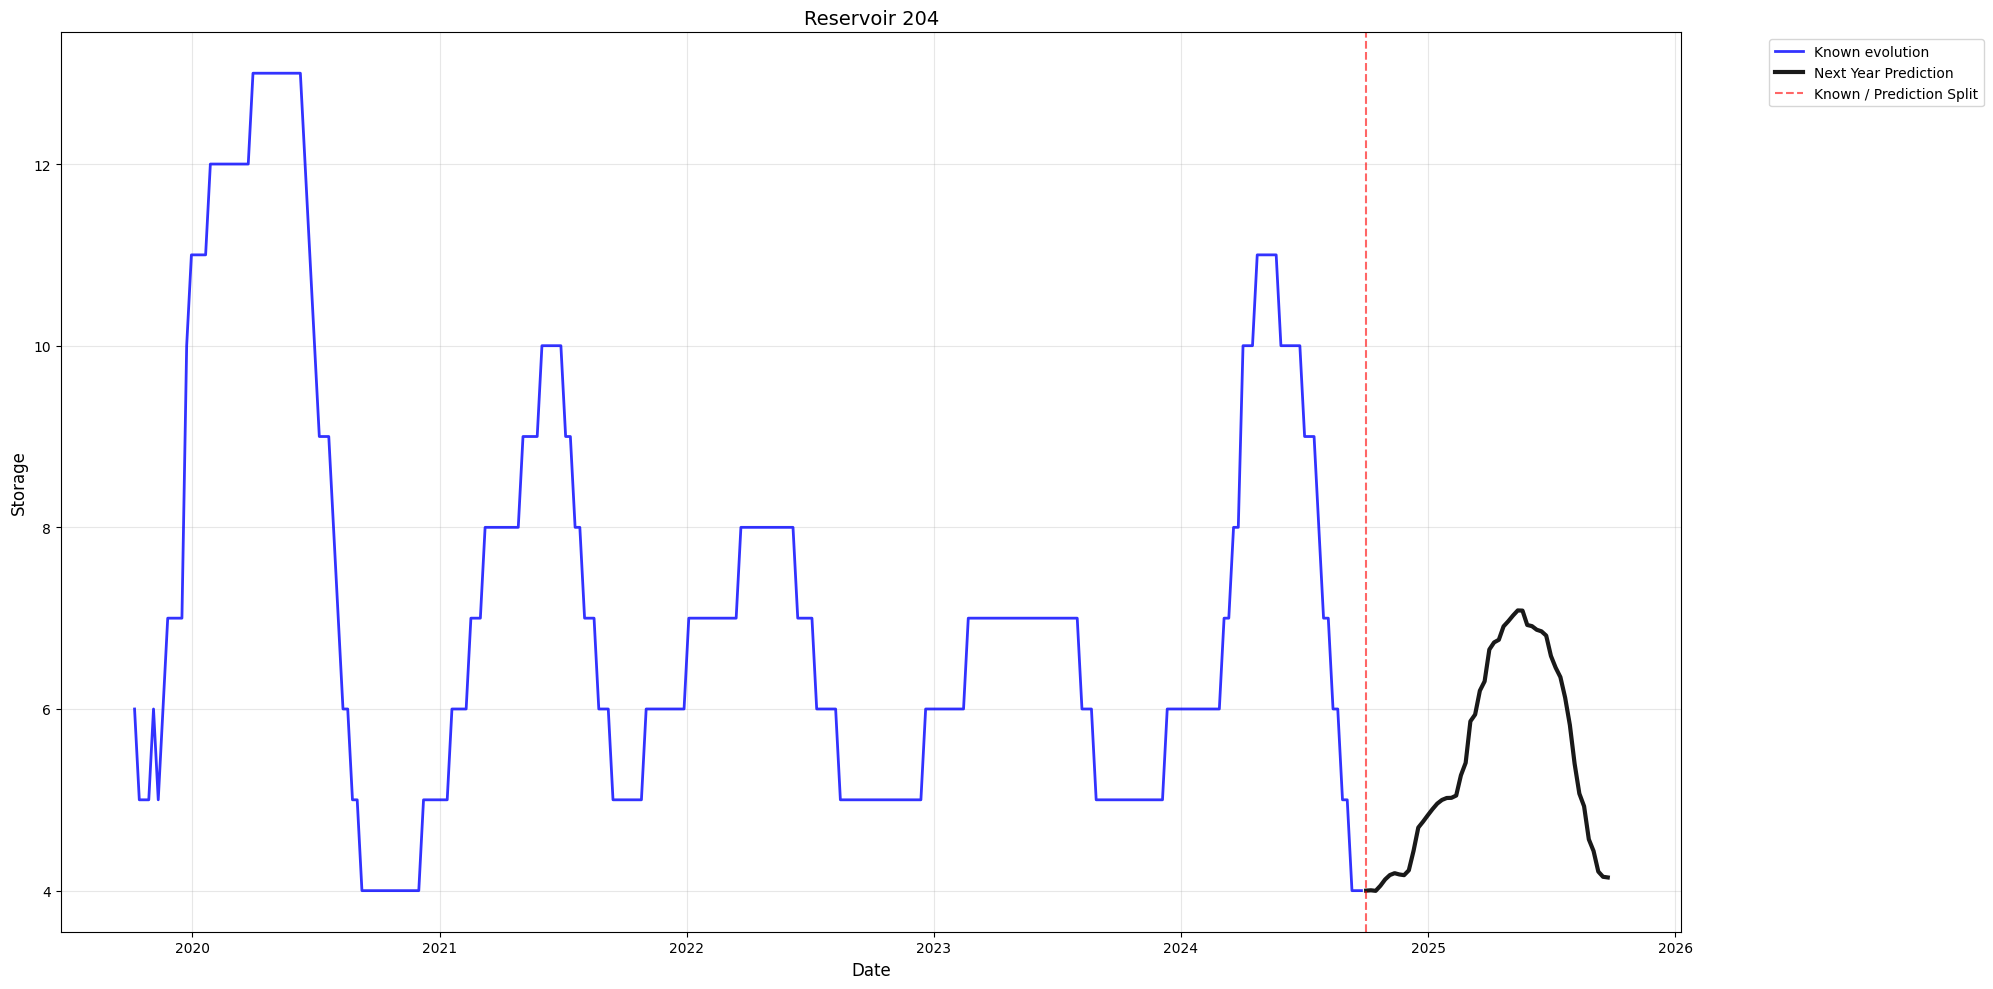

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

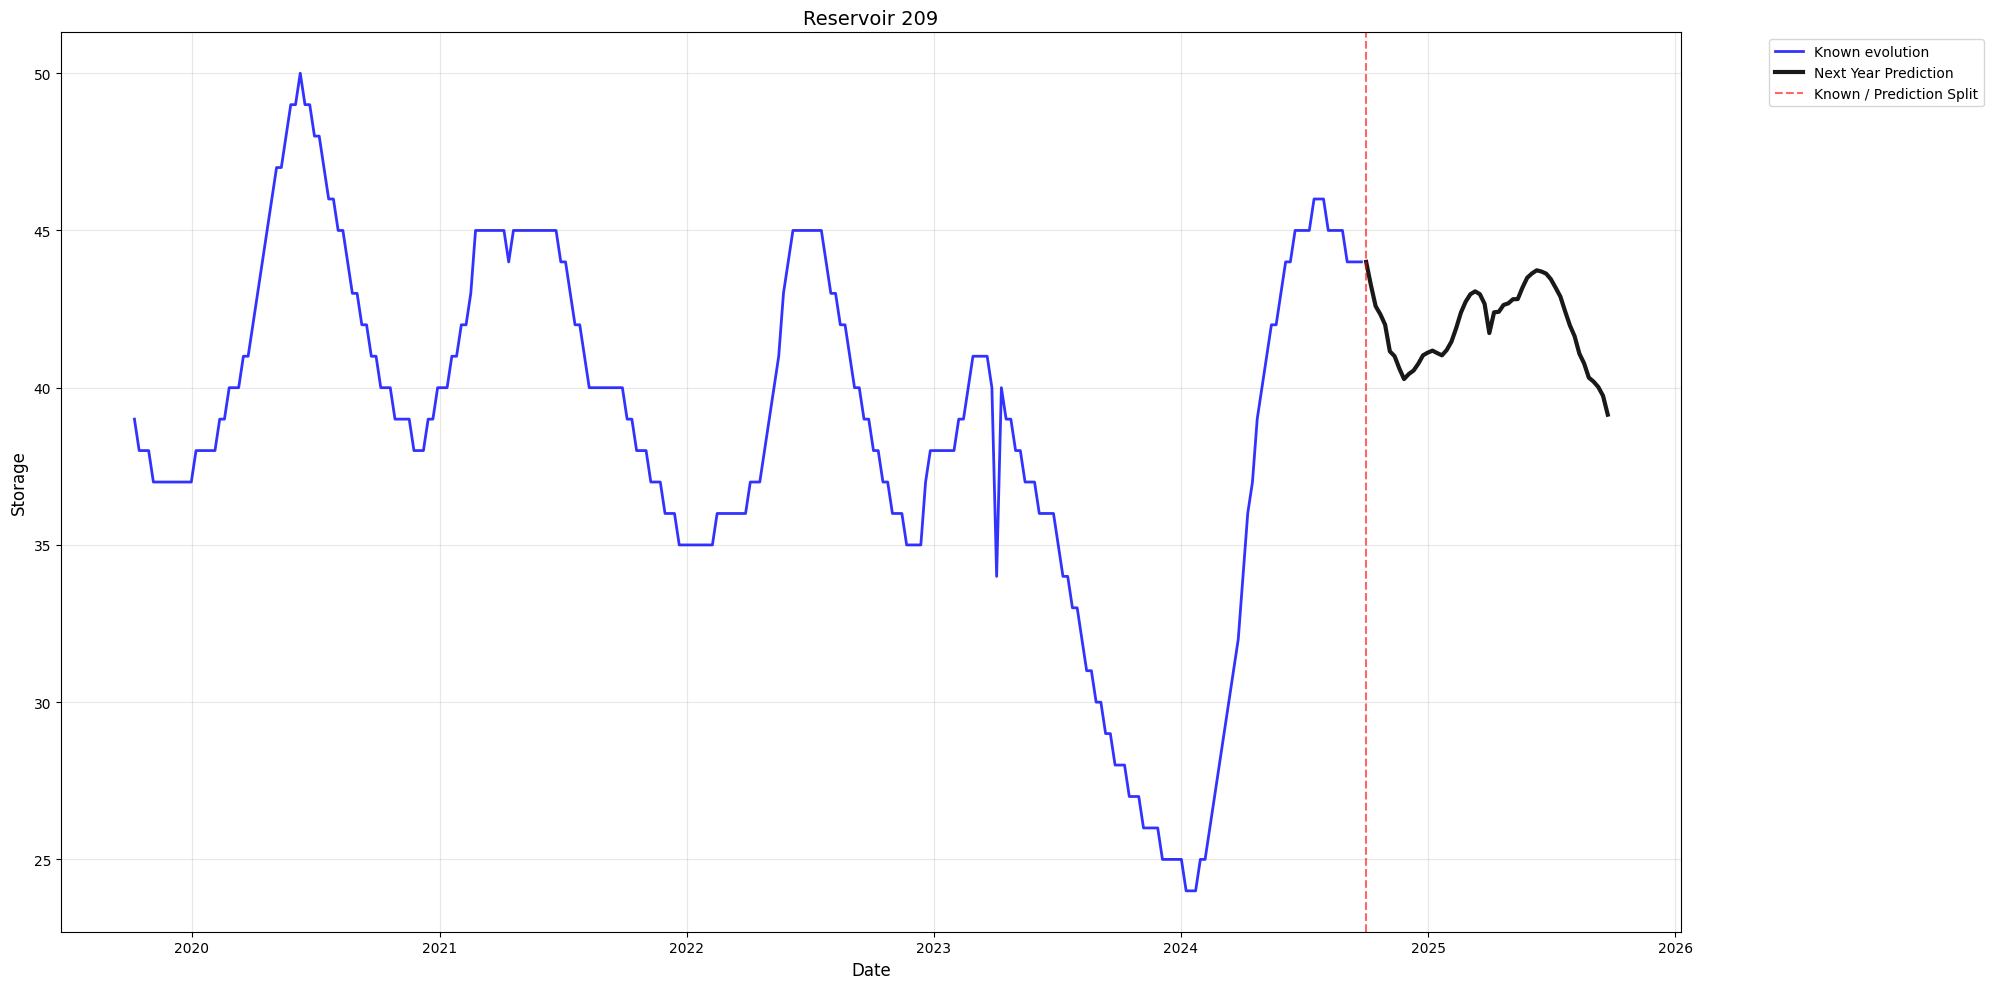

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

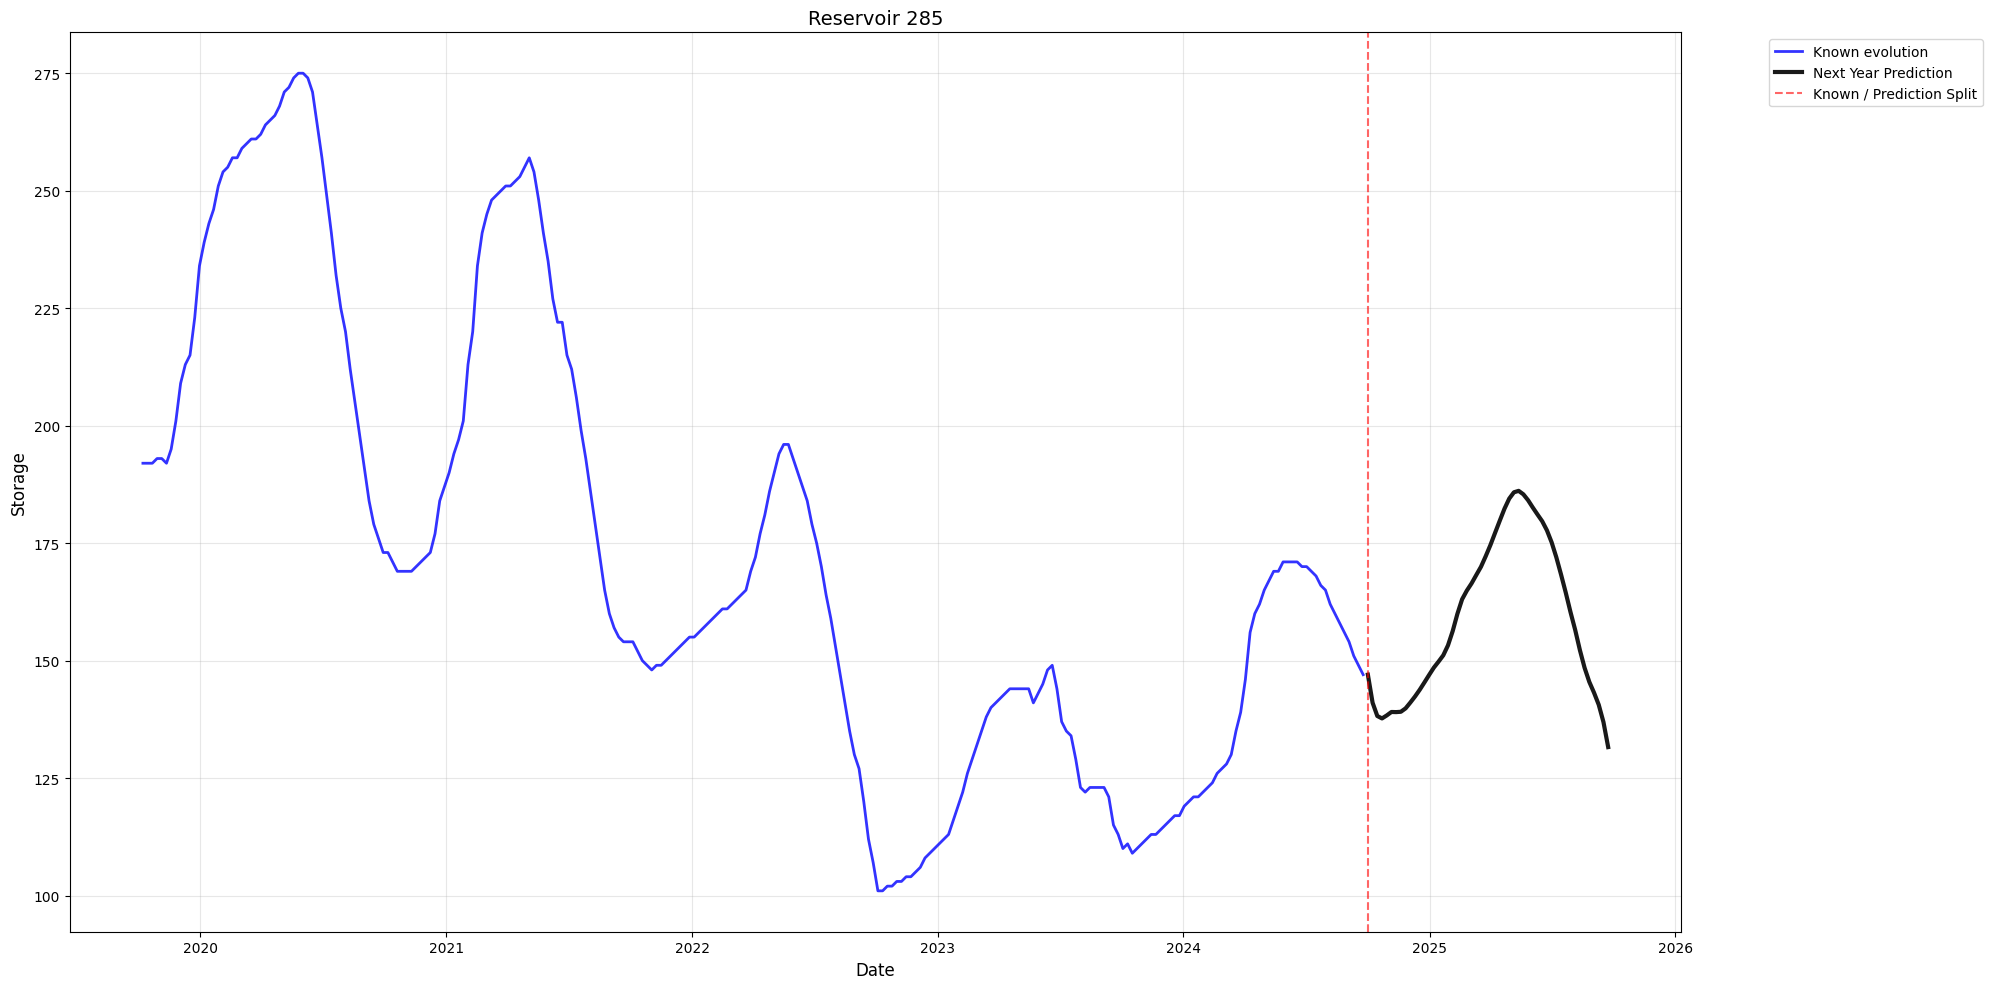

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

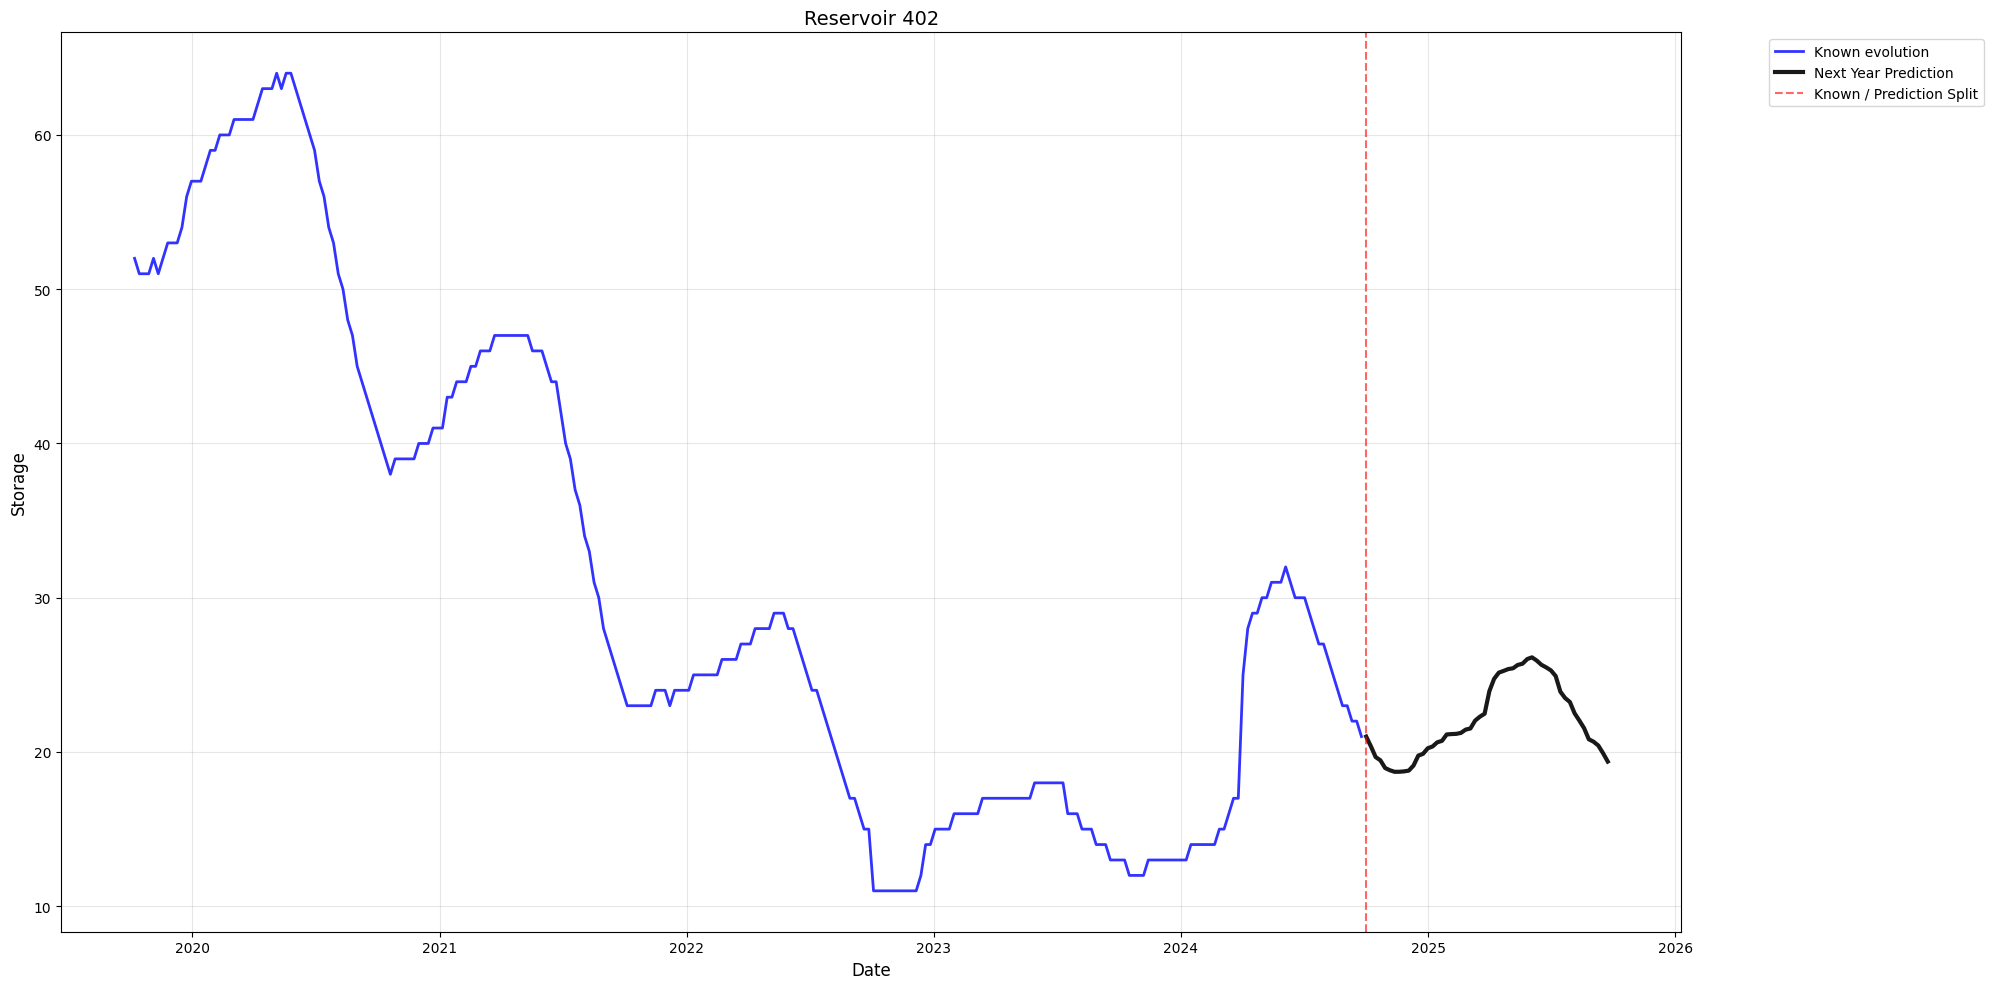

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

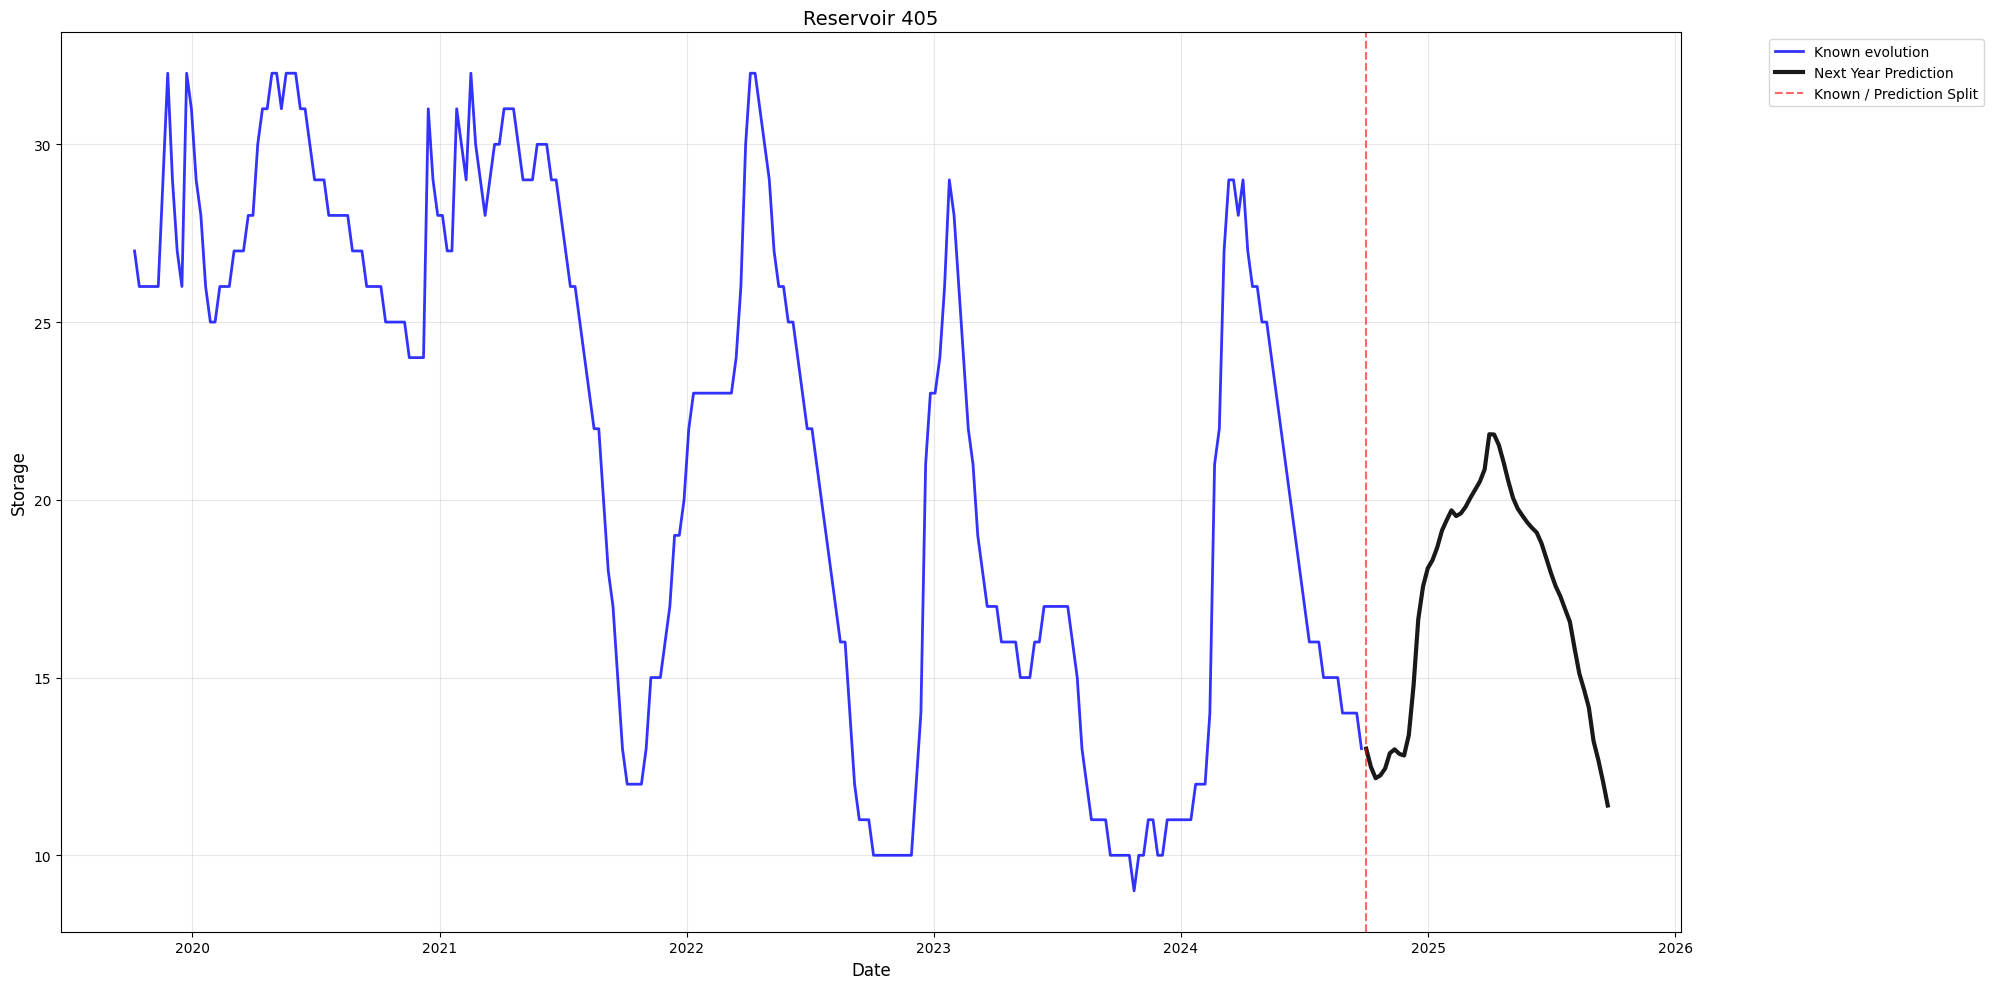

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(date

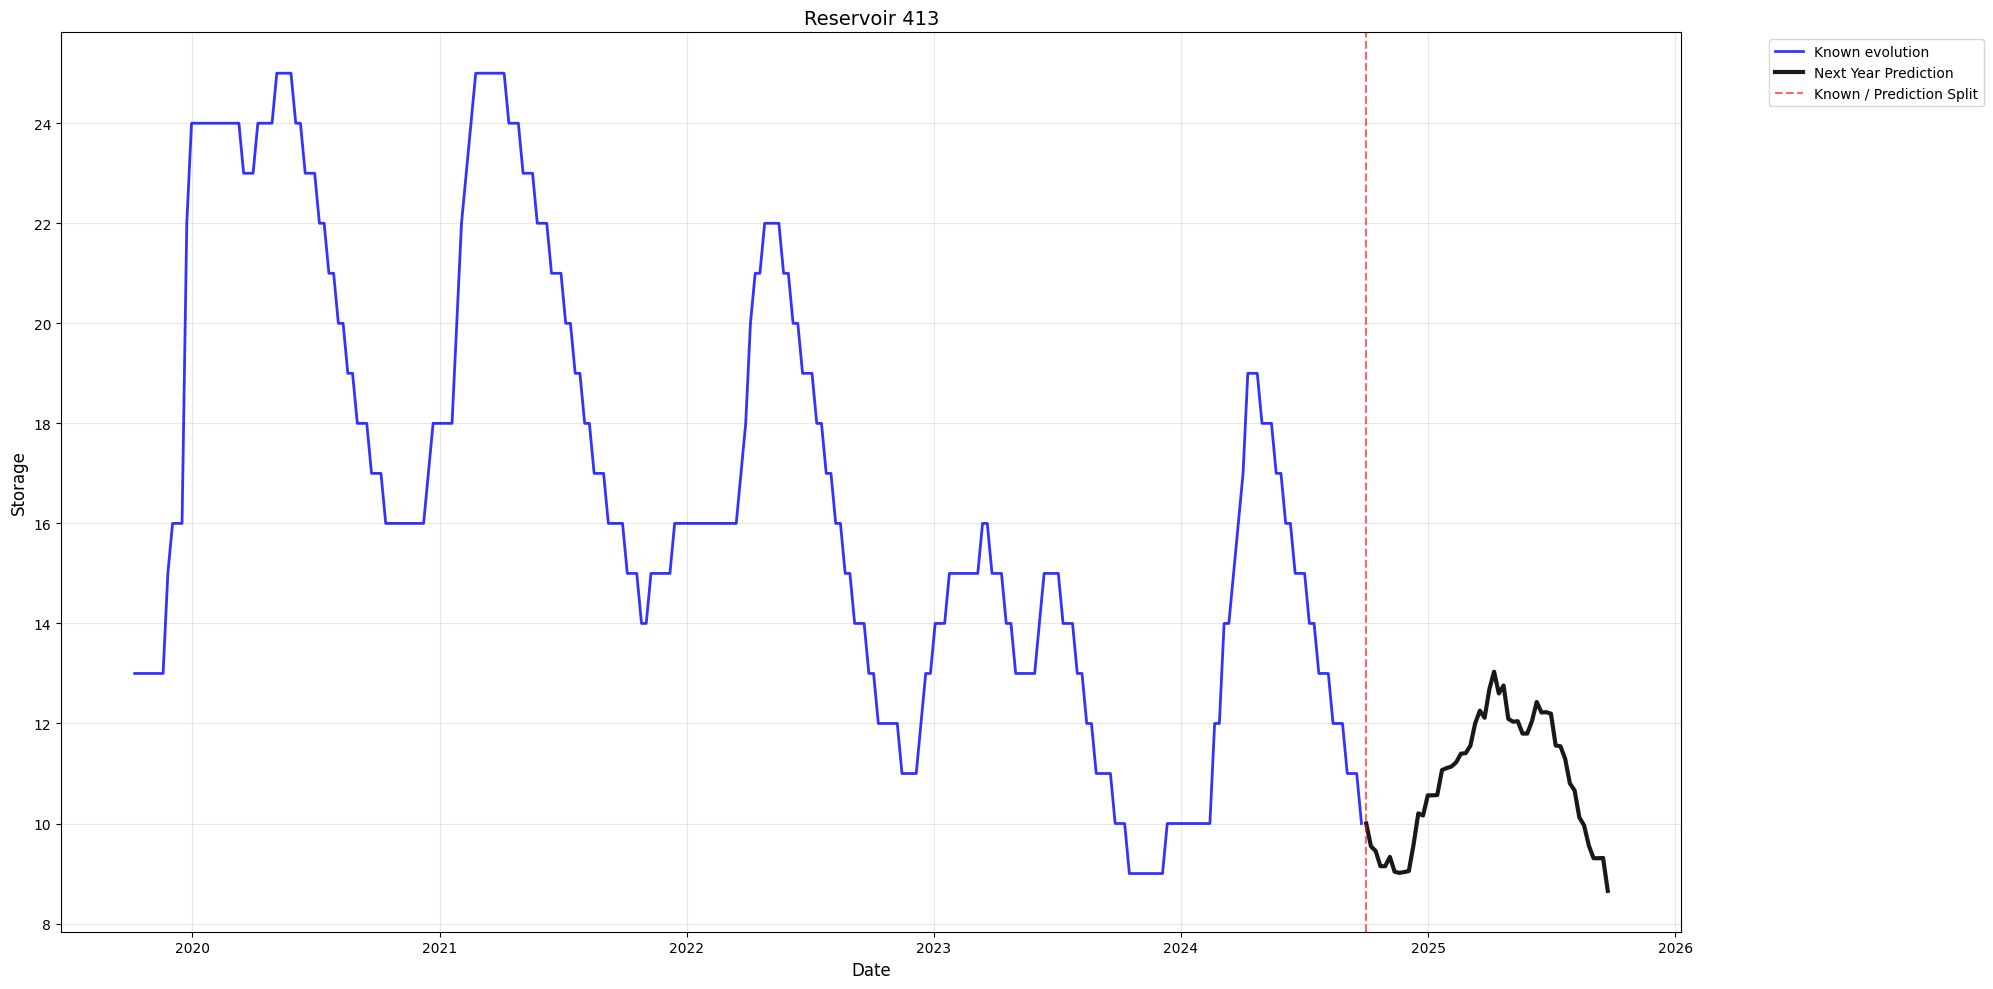

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


KeyboardInterrupt: 

In [15]:
reservoirs = sorted(reservoirs_pd[reservoirs_pd['province'] == 'granada']['id'].values)
reservoirs_definitive, transfers_log = make_optimal_transfers(reservoirs)

In [59]:
reservoirs_definitive

,name,capacity,latitude,longitude,crest_elevation,last_known_value,low_forecasted_value,high_forecasted_value,median_forecasted_value,urgent_need_to_receive_rate,ability_to_transfer_rate,critical,worrying,could_give_if_critical,could_give_if_worrying,able_to_donate
id,,,,,,,,,,,,,,,,
324,beninar,70,36.887925,-3.030057,NaN,5.0,4.703477,5.972652,5.000000,0.067193,0.071429,1,1,0,0,0
570,cuevas almanzora,168,37.327593,-1.896736,474.0,13.0,9.705215,12.544252,10.712814,0.057769,0.063767,1,1,0,0,0


In [ ]:
transfers_log

[11, 61, 65, 204, 209, 285, 402, 405, 413, 471, 658]

In [66]:
reservoirs = sorted(reservoirs_pd[reservoirs_pd['province'] == 'granada']['id'].values)
reservoirs

[11, 61, 65, 204, 209, 285, 402, 405, 413, 471, 658]